# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

%matplotlib inline
sns.set(style='whitegrid')

# 2. Load Data

In [2]:
df= pd.read_csv("Ecommerce_Customers.csv")
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


# 3. Data Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [4]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [5]:
print("Missing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

Duplicate rows: 0


**The dataset has 500 rows and 8 columns with no missing values 
and no duplicate rows. It is clean and ready for modeling.**

# 4. EDA

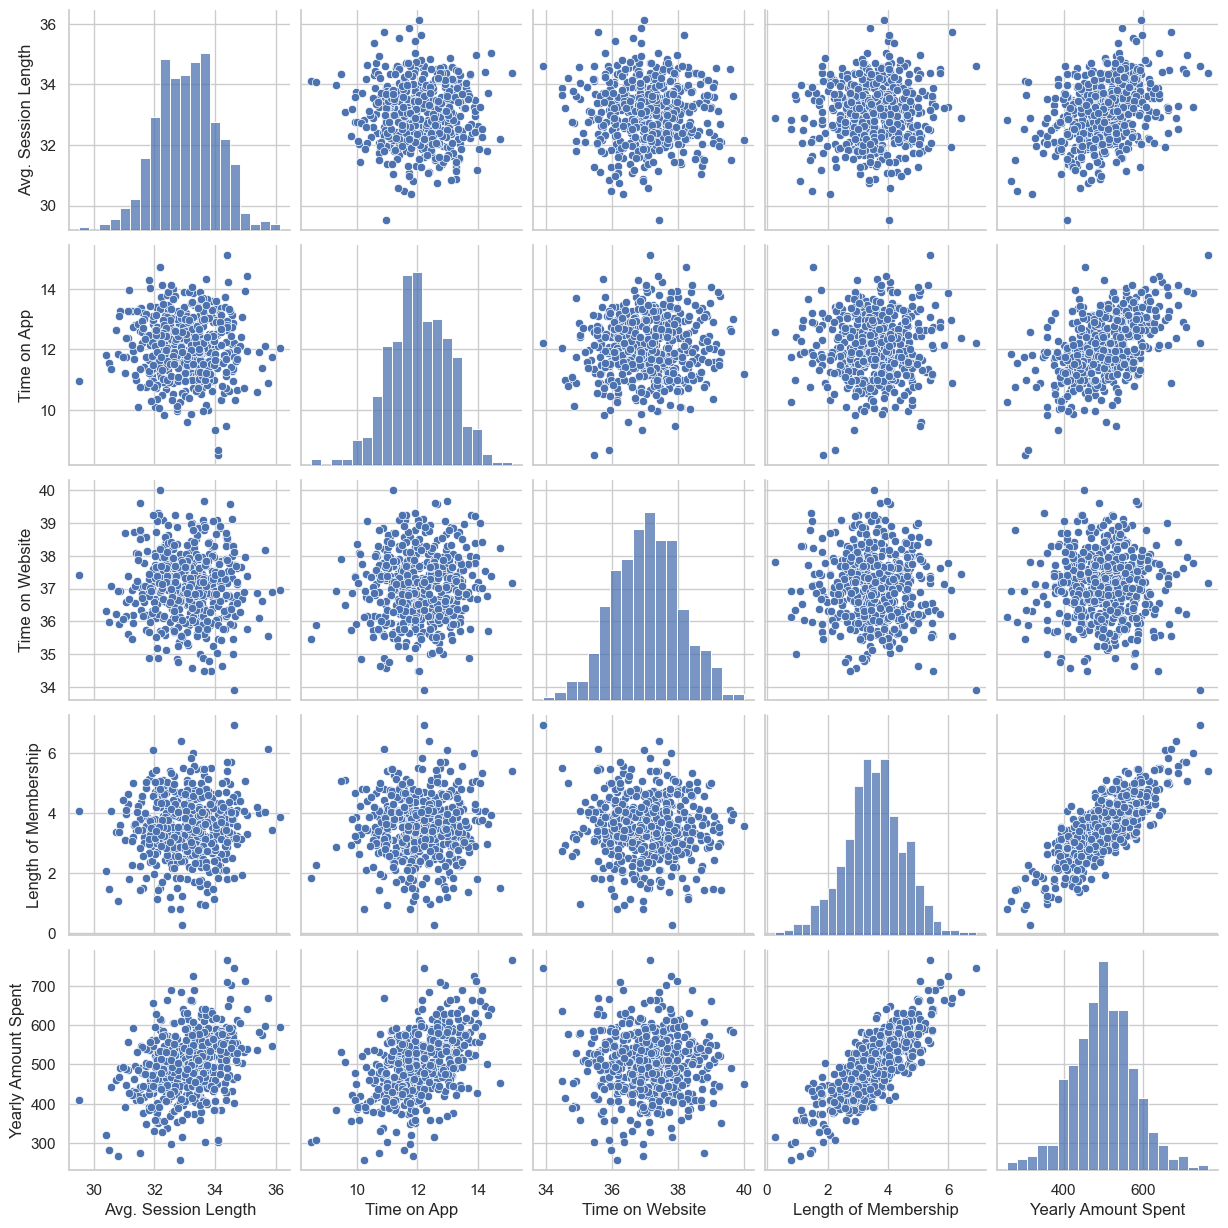

In [6]:
sns.pairplot(df[['Avg. Session Length', 'Time on App', 
                  'Time on Website', 'Length of Membership', 
                  'Yearly Amount Spent']])
plt.show()

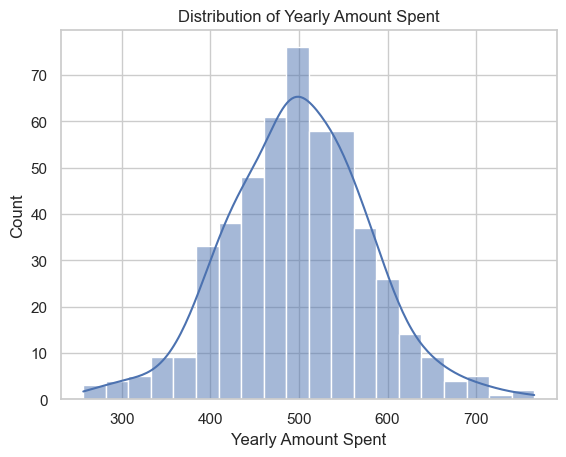

In [7]:
sns.histplot(df['Yearly Amount Spent'], kde=True)
plt.title("Distribution of Yearly Amount Spent")
plt.show()

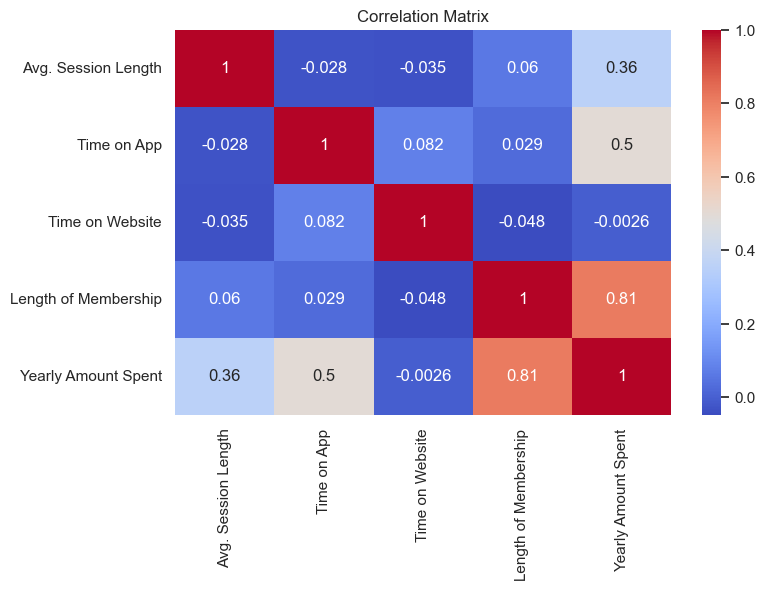

In [8]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['Avg. Session Length', 'Time on App', 
                 'Time on Website', 'Length of Membership', 
                 'Yearly Amount Spent']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**The pairplot shows Length of Membership and Time on App have 
the strongest relationship with Yearly Amount Spent. The 
heatmap confirms this with correlations of 0.81 and 0.5.**

# 5. Prepare Data for Modeling

In [9]:
# Drop non-useful columns
df = df.drop(columns=['Email', 'Address', 'Avatar'])

X = df[['Avg. Session Length', 'Time on App', 
        'Time on Website', 'Length of Membership']]
y = df['Yearly Amount Spent']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 4)
y shape: (500,)


**Email, Address, and Avatar are dropped as they carry no 
predictive value. The 4 numerical features are used as input 
to predict Yearly Amount Spent.**

# 6. Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (350, 4)
Test size: (150, 4)


**I use 70% of data for training and 30% for testing with a 
fixed random state for reproducibility.**

# 7. Train the Model

In [11]:
lm = LinearRegression()
lm.fit(X_train, y_train)

# Coefficients
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

                      Coefficient
Avg. Session Length     25.981550
Time on App             38.590159
Time on Website          0.190405
Length of Membership    61.279097


**Length of Membership has the highest coefficient (61.27) 
meaning it is the strongest predictor of yearly spending. 
Time on Website has almost no effect (0.19).**

# 8. Predictions

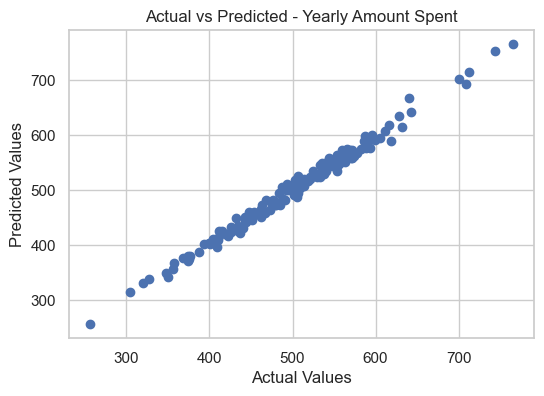

In [12]:
predictions = lm.predict(X_test)

# Scatter plot: actual vs predicted
plt.figure(figsize=(6,4))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Yearly Amount Spent")
plt.show()

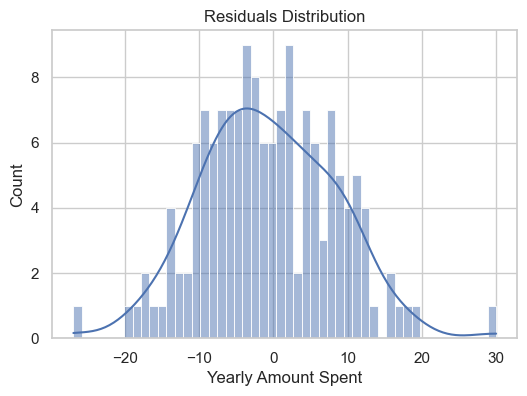

In [13]:
# Residual plot
plt.figure(figsize=(6,4))
sns.histplot((y_test - predictions), bins=50, kde=True)
plt.title("Residuals Distribution")
plt.show()

**The scatter plot shows predicted values are very close to 
actual values. The residuals are normally distributed around 
zero confirming the model assumptions are met.**

# 9. Model Evaluation

In [14]:
print('MAE: ', metrics.mean_absolute_error(y_test, predictions))
print('MSE: ', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('R2 Score:', metrics.r2_score(y_test, predictions))

MAE:  7.228148653430832
MSE:  79.81305165097444
RMSE: 8.933815066978633
R2 Score: 0.9890046246741234


**MAE of 7.23 means predictions are off by about $7 on average. 
R2 of 0.989 means the model explains 98.9% of the variance in 
Yearly Amount Spent which indicates excellent model performance.**